In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


In [4]:
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [3]:
# STEP 1: LOAD DATASETS
# Upload files in Colab
from google.colab import files
print("\n📁 Please upload the TRADER DATA CSV file:")
uploaded_trader = files.upload()
trader_file = list(uploaded_trader.keys())[0]


📁 Please upload the TRADER DATA CSV file:


Saving historical_data.csv to historical_data.csv


In [47]:
# Load datasets
df_trader = pd.read_csv('/content/historical_data.csv')


In [48]:
print(f"\n Trader Data: {df_trader.shape[0]:,} rows × {df_trader.shape[1]} columns")



 Trader Data: 211,224 rows × 16 columns


In [15]:
# STEP 2: DATA INSPECTION
print("\n[2] DATA INSPECTION")
print("\n" + "─" * 70)
print("TRADER DATA - First 5 rows:")
print("─" * 70)
display(df_trader.head())


[2] DATA INSPECTION

──────────────────────────────────────────────────────────────────────
TRADER DATA - First 5 rows:
──────────────────────────────────────────────────────────────────────


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [16]:
print("\n" + "─" * 70)
print("TRADER DATA - Column Info:")
print("─" * 70)
df_trader.info()


──────────────────────────────────────────────────────────────────────
TRADER DATA - Column Info:
──────────────────────────────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   

In [56]:
print("\n Statistical Summary:")
print(df_trader.describe())




 Statistical Summary:
       Execution Price   Size Tokens      Size USD  Start Position  \
count    211224.000000  2.112240e+05  2.112240e+05    2.112240e+05   
mean      11414.723350  4.623365e+03  5.639451e+03   -2.994625e+04   
std       29447.654868  1.042729e+05  3.657514e+04    6.738074e+05   
min           0.000005  8.740000e-07  0.000000e+00   -1.433463e+07   
25%           4.854700  2.940000e+00  1.937900e+02   -3.762311e+02   
50%          18.280000  3.200000e+01  5.970450e+02    8.472793e+01   
75%         101.580000  1.879025e+02  2.058960e+03    9.337278e+03   
max      109004.000000  1.582244e+07  3.921431e+06    3.050948e+07   

          Closed PnL      Order ID            Fee      Trade ID     Timestamp  
count  211224.000000  2.112240e+05  211224.000000  2.112240e+05  2.112240e+05  
mean       48.749001  6.965388e+10       1.163967  5.628549e+14  1.737744e+12  
std       919.164828  1.835753e+10       6.758854  3.257565e+14  8.689920e+09  
min   -117990.104100  1.73

In [55]:
print("\n Missing Values:")
print(df_trader.isnull().sum())




 Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [58]:
print("\n Unique Values:")
print(f"Unique Accounts: {df_trader['Account'].nunique()}")
print(f"Unique Coins: {df_trader['Coin'].nunique()}")
print(f"Trading Sides: {df_trader['Side'].unique()}")


 Unique Values:
Unique Accounts: 32
Unique Coins: 246
Trading Sides: ['BUY' 'SELL']


In [49]:
# STEP 3: DATA CLEANING
print("\n[3] DATA CLEANING")

# Clean trader data
df_trader_clean = df_trader.copy()

# Convert time to datetime
if 'time' in df_trader_clean.columns:
    df_trader_clean['time'] = pd.to_datetime(df_trader_clean['time'])
    df_trader_clean['date'] = df_trader_clean['time'].dt.date
    df_trader_clean['hour'] = df_trader_clean['time'].dt.hour
    df_trader_clean['day_of_week'] = df_trader_clean['time'].dt.dayofweek



[3] DATA CLEANING


In [50]:
# Check missing values
print("\n📊 Missing Values in Trader Data:")
print(df_trader_clean.isnull().sum()[df_trader_clean.isnull().sum() > 0])



📊 Missing Values in Trader Data:
Series([], dtype: int64)


In [51]:
# Handle missing values in critical columns
if 'closedPnL' in df_trader_clean.columns:
    df_trader_clean['closedPnL'] = df_trader_clean['closedPnL'].fillna(0)

print(f"\n Cleaned Data - Trader: {df_trader_clean.shape[0]:,} rows")




 Cleaned Data - Trader: 211,224 rows


In [62]:
# STEP 4: PROFITABILITY ANALYSIS
print("\n[STEP 4] PROFITABILITY ANALYSIS")
print("-" * 80)

total_pnl = df_trader['Closed PnL'].sum()
avg_pnl = df_trader['Closed PnL'].mean()
median_pnl = df_trader['Closed PnL'].median()
profitable_trades = (df_trader['Closed PnL'] > 0).sum()
losing_trades = (df_trader['Closed PnL'] < 0).sum()
neutral_trades = (df_trader['Closed PnL'] == 0).sum()
win_rate = (profitable_trades / len(df_trader)) * 100

print(f"\n 1.OVERALL PnL METRICS:")
print(f"   Total PnL: ${total_pnl:,.2f}")
print(f"   Average PnL: ${avg_pnl:,.2f}")
print(f"   Median PnL: ${median_pnl:,.2f}")
print(f"   Max Profit: ${df_trader['Closed PnL'].max():,.2f}")
print(f"   Max Loss: ${df_trader['Closed PnL'].min():,.2f}")

print(f"\n 2.TRADE BREAKDOWN:")
print(f"   Profitable Trades: {profitable_trades:,} ({win_rate:.2f}%)")
print(f"   Losing Trades: {losing_trades:,} ({(losing_trades/len(df_trader))*100:.2f}%)")
print(f"   Neutral Trades: {neutral_trades:,}")
print(f"   Total Trades: {len(df_trader):,}")


[STEP 4] PROFITABILITY ANALYSIS
--------------------------------------------------------------------------------

 1.OVERALL PnL METRICS:
   Total PnL: $10,296,958.94
   Average PnL: $48.75
   Median PnL: $0.00
   Max Profit: $135,329.09
   Max Loss: $-117,990.10

 2.TRADE BREAKDOWN:
   Profitable Trades: 86,869 (41.13%)
   Losing Trades: 17,539 (8.30%)
   Neutral Trades: 106,816
   Total Trades: 211,224


In [75]:
# Convert Timestamp IST to datetime
df_trader['Timestamp IST'] = pd.to_datetime(df_trader['Timestamp IST'], dayfirst=True)
df_trader['date'] = df_trader['Timestamp IST'].dt.date  # date column for future merge

# Total trades
print(f"Total trades: {df_trader.shape[0]:,}")




Total trades: 211,224


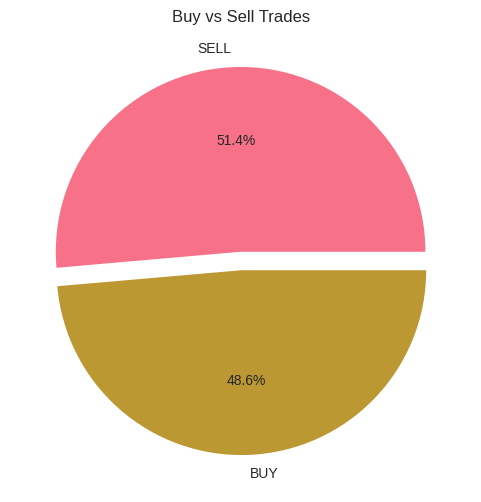

In [76]:
# 2️ Buy vs Sell trades
plt.figure(figsize=(6,6))
df_trader['Side'].value_counts().plot(kind='pie', autopct='%1.1f%%', explode=[0.05,0.05])
plt.title("Buy vs Sell Trades")
plt.ylabel("")
plt.show()

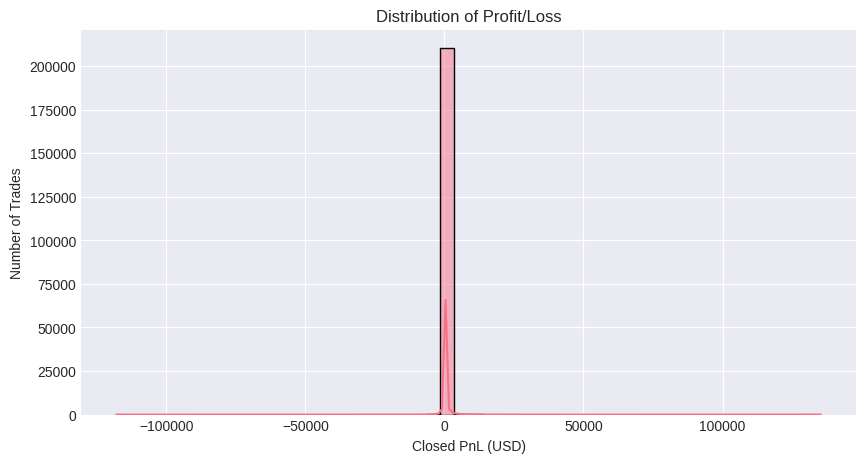

In [78]:
# 3️ Closed PnL distribution
plt.figure(figsize=(10,5))
sns.histplot(df_trader['Closed PnL'], bins=50, kde=True)
plt.title("Distribution of Profit/Loss")
plt.xlabel("Closed PnL (USD)")
plt.ylabel("Number of Trades")
plt.show()

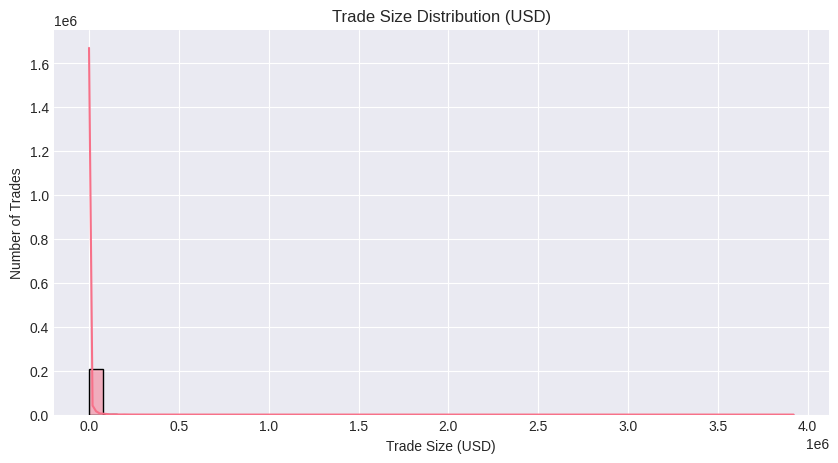

In [80]:
# 4️ Trade Size distribution
plt.figure(figsize=(10,5))
sns.histplot(df_trader['Size USD'], bins=50, kde=True)
plt.title("Trade Size Distribution (USD)")
plt.xlabel("Trade Size (USD)")
plt.ylabel("Number of Trades")
plt.show()


Top 10 Traders by Total Profit:
Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


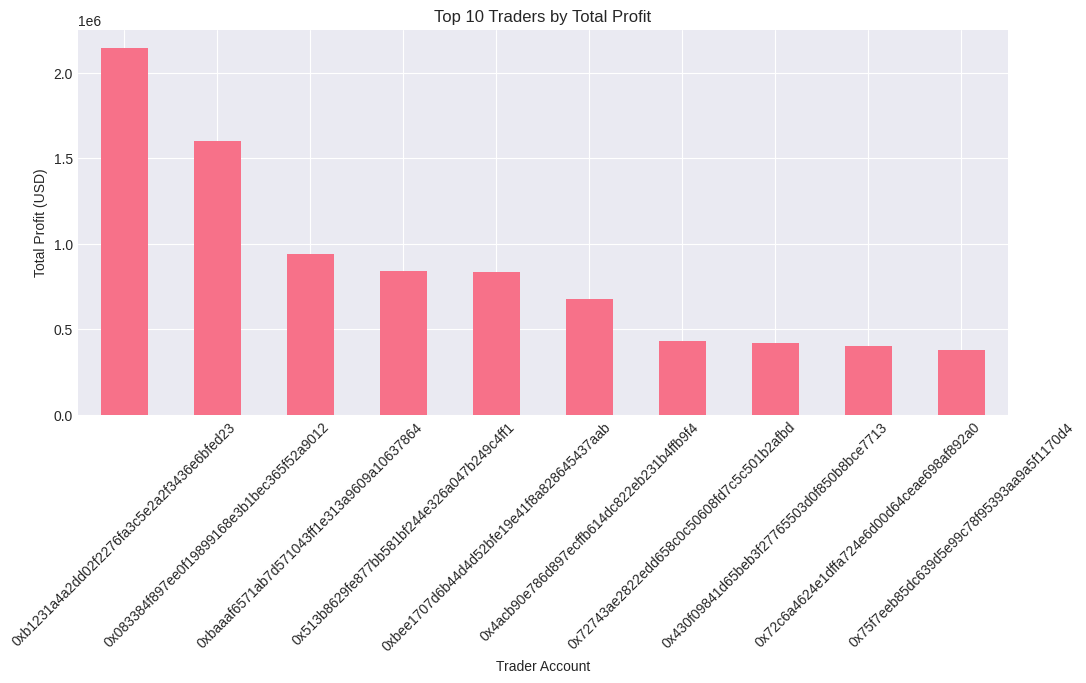

In [82]:
# 5️ Top 10 Traders by Total Profit
top_traders = df_trader.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Traders by Total Profit:")
print(top_traders)
plt.figure(figsize=(12,5))
top_traders.plot(kind='bar')
plt.title("Top 10 Traders by Total Profit")
plt.ylabel("Total Profit (USD)")
plt.xlabel("Trader Account")
plt.xticks(rotation=45)
plt.show()

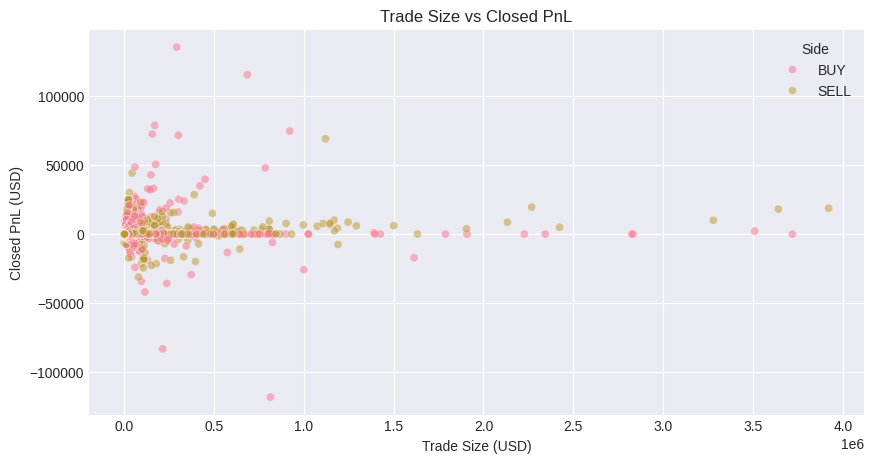

In [85]:
# Trade Size vs PnL Scatter
plt.figure(figsize=(10,5))
sns.scatterplot(x='Size USD', y='Closed PnL', hue='Side', data=df_trader, alpha=0.5)
plt.title("Trade Size vs Closed PnL")
plt.xlabel("Trade Size (USD)")
plt.ylabel("Closed PnL (USD)")
plt.show()


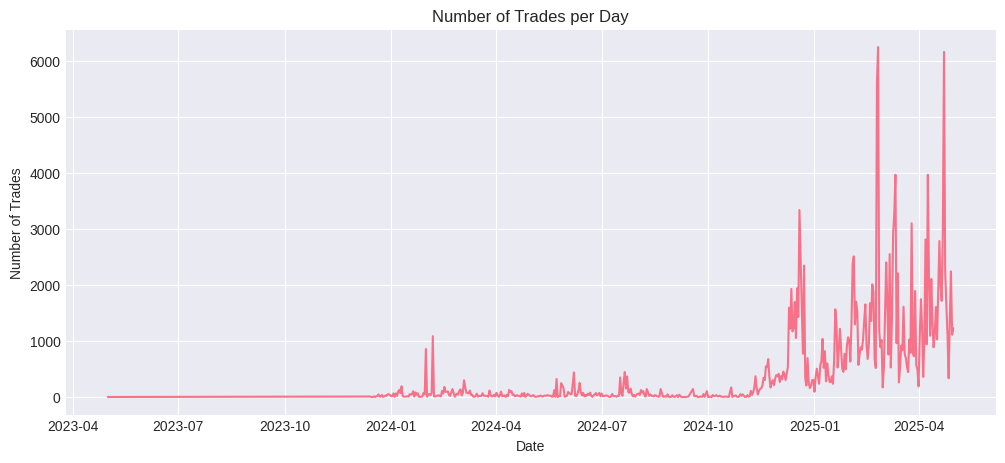

In [87]:
# Daily Trading Activity
trades_per_day = df_trader.groupby('date').size()
plt.figure(figsize=(12,5))
trades_per_day.plot()
plt.title("Number of Trades per Day")
plt.xlabel("Date")
plt.ylabel("Number of Trades")
plt.show()


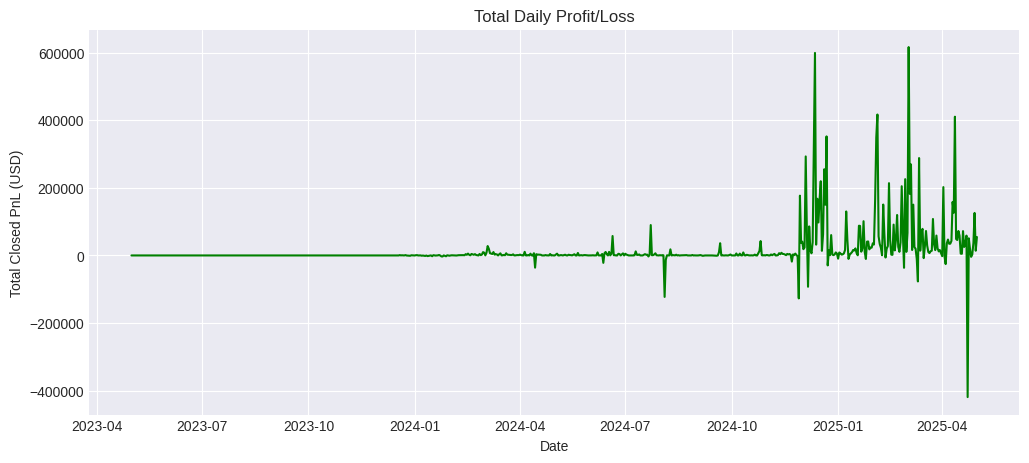

In [89]:
# Daily Profit Trend
daily_profit = df_trader.groupby('date')['Closed PnL'].sum()
plt.figure(figsize=(12,5))
daily_profit.plot(color='green')
plt.title("Total Daily Profit/Loss")
plt.xlabel("Date")
plt.ylabel("Total Closed PnL (USD)")
plt.show()


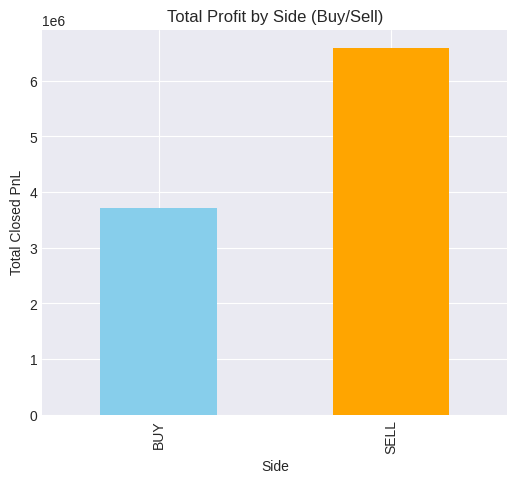

In [91]:
# Side Analysis by Profit
side_profit = df_trader.groupby('Side')['Closed PnL'].sum()
plt.figure(figsize=(6,5))
side_profit.plot(kind='bar', color=['skyblue', 'orange'])
plt.title("Total Profit by Side (Buy/Sell)")
plt.ylabel("Total Closed PnL")
plt.show()


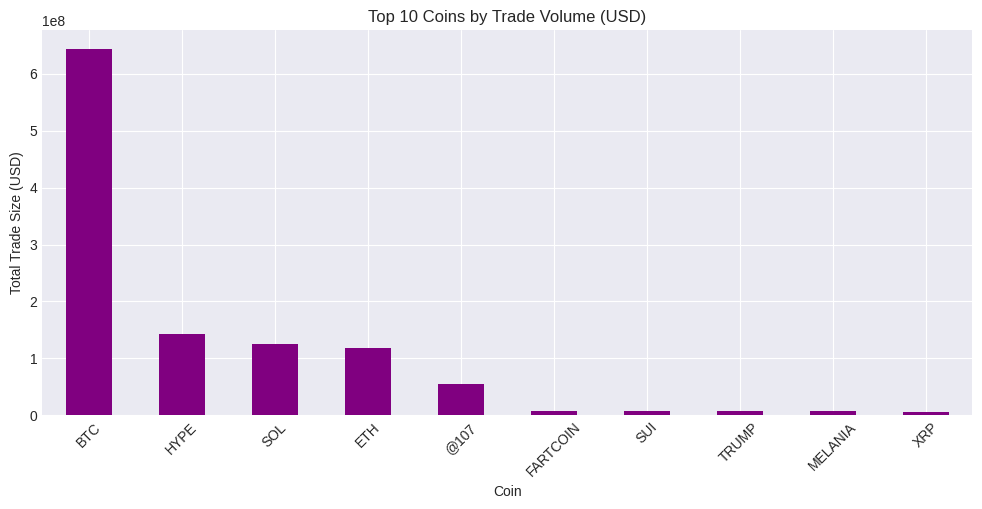

In [92]:
# Top Coins by Volume
top_coins = df_trader.groupby('Coin')['Size USD'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,5))
top_coins.plot(kind='bar', color='purple')
plt.title("Top 10 Coins by Trade Volume (USD)")
plt.ylabel("Total Trade Size (USD)")
plt.xlabel("Coin")
plt.xticks(rotation=45)
plt.show()


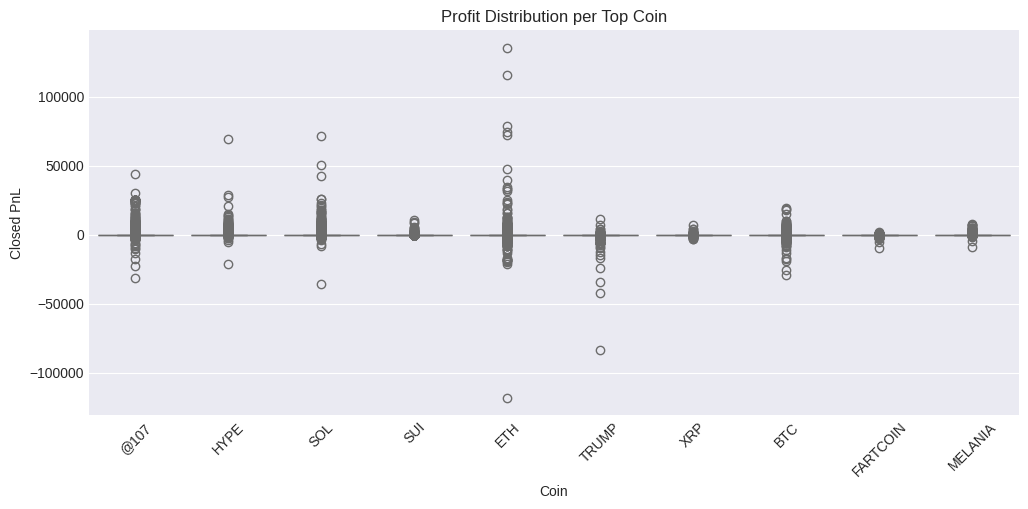

In [94]:
# Profit Distribution per Coin
plt.figure(figsize=(12,5))
sns.boxplot(x='Coin', y='Closed PnL', data=df_trader[df_trader['Coin'].isin(top_coins.index)])
plt.title("Profit Distribution per Top Coin")
plt.xlabel("Coin")
plt.ylabel("Closed PnL")
plt.xticks(rotation=45)
plt.show()


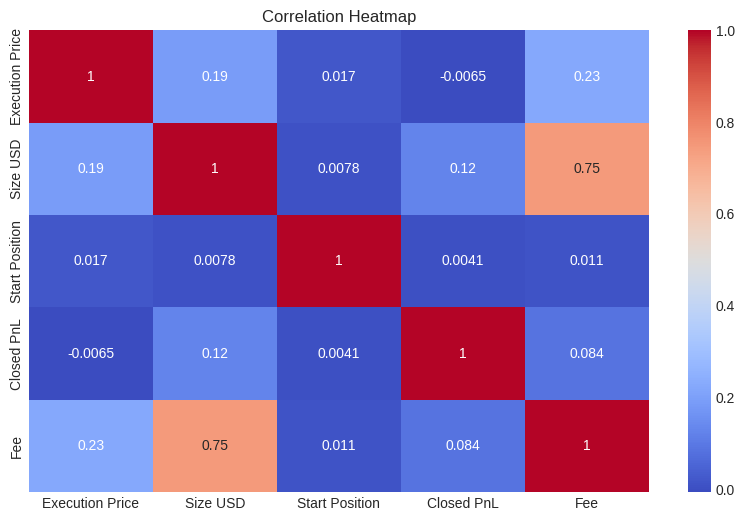

In [97]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df_trader[['Execution Price', 'Size USD', 'Start Position', 'Closed PnL', 'Fee']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


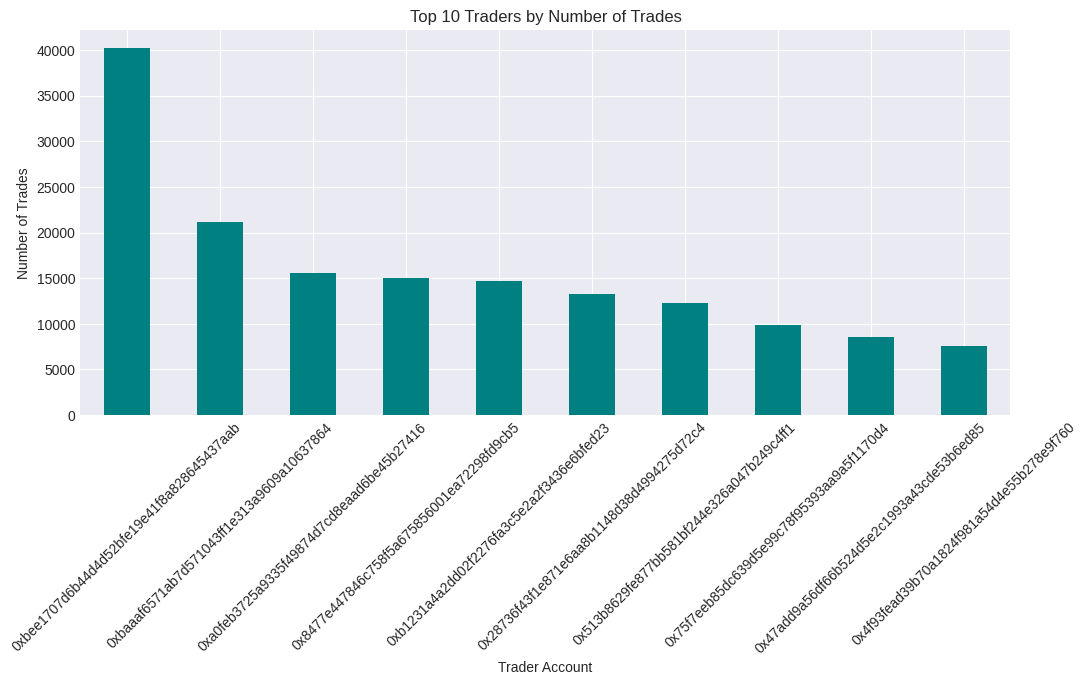

In [98]:
# Top Traders by Trade Count
top_traders_count = df_trader['Account'].value_counts().head(10)
plt.figure(figsize=(12,5))
top_traders_count.plot(kind='bar', color='teal')
plt.title("Top 10 Traders by Number of Trades")
plt.ylabel("Number of Trades")
plt.xlabel("Trader Account")
plt.xticks(rotation=45)
plt.show()


In [101]:
import os

# Create 'outputs' folder
if not os.path.exists('outputs'):
    os.makedirs('outputs')

# Now save the cleaned CSV
df_trader.to_csv('outputs/historical_data_cleaned.csv', index=False)
print("Cleaned data saved in 'outputs/historical_data_cleaned.csv'")


Cleaned data saved in 'outputs/historical_data_cleaned.csv'
